In [1]:
# =============================================================================
# SECTION 0: INSTALL AND IMPORT LIBRARIES
# =============================================================================

# Uncomment the line below if you need to install any missing libraries
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set visual style for all plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [2]:
# =============================================================================
# SECTION 1: LOAD YOUR DATASET FROM LOCAL DEVICE
# ============================================================================

df = pd.read_csv('student_mental_health.csv')

In [3]:
# =============================================================================
# SECTION 2: DATA PREPROCESSING
# =============================================================================

# Make a copy to preserve original data
data = df.copy()

# --- 2.1 Check for Missing Values ---
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

missing_values = data.isnull().sum()
missing_percentage = (missing_values / len(data)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage': missing_percentage
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False)

if len(missing_df) > 0:
    print("\n⚠️ Columns with missing values:")
    print(missing_df)
    
    # Handle missing values
    # For numerical columns: fill with median (robust to outliers)
    # For categorical columns: fill with mode (most frequent value)
    
    for column in data.columns:
        if data[column].isnull().sum() > 0:
            if data[column].dtype in ['int64', 'float64']:
                median_value = data[column].median()
                data[column].fillna(median_value, inplace=True)
                print(f"   → Filled '{column}' with median: {median_value:.2f}")
            else:
                mode_value = data[column].mode()[0]
                data[column].fillna(mode_value, inplace=True)
                print(f"   → Filled '{column}' with mode: {mode_value}")
    
    print("\n✅ All missing values handled!")
else:
    print("\n✅ No missing values found in the dataset!")

# --- 2.2 Identify Column Types ---
print("\n" + "=" * 60)
print("COLUMN DATA TYPES")
print("=" * 60)

numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\n📊 Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"\n📝 Categorical columns ({len(categorical_cols)}): {categorical_cols}")

# --- 2.3 Encode Categorical Variables ---
print("\n" + "=" * 60)
print("ENCODING CATEGORICAL VARIABLES")
print("=" * 60)

# Store encoders for later use (if needed for new predictions)
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    data[col + '_encoded'] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le
    print(f"   → Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\n✅ All categorical variables encoded!")

# --- 2.4 Create Target Variable (Dropout Percentage) ---
print("\n" + "=" * 60)
print("TARGET VARIABLE CREATION")
print("=" * 60)

# Check if 'dropout_risk' column exists (adjust name if different in your dataset)
target_column = None
for col in data.columns:
    if 'dropout' in col.lower() and 'risk' in col.lower():
        target_column = col
        break

if target_column is None:
    # If not found, show available columns and ask user to specify
    print("⚠️ Could not automatically find 'dropout_risk' column.")
    print(f"Available columns: {data.columns.tolist()}")
    target_column = input("Please enter the exact name of your target column: ")

# Convert to percentage (0-100 scale)
data['dropout_percentage'] = data[target_column] * 10

print(f"✅ Created 'dropout_percentage' from '{target_column}'")
print(f"   Range: {data['dropout_percentage'].min():.1f}% to {data['dropout_percentage'].max():.1f}%")
print(f"   Mean: {data['dropout_percentage'].mean():.1f}%")


MISSING VALUES ANALYSIS

✅ No missing values found in the dataset!

COLUMN DATA TYPES

📊 Numerical columns (18): ['age', 'academic_year', 'study_hours_per_day', 'exam_pressure', 'academic_performance', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity', 'social_support', 'screen_time', 'internet_usage', 'financial_stress', 'family_expectation', 'burnout_score', 'mental_health_index', 'dropout_risk']

📝 Categorical columns (2): ['gender', 'risk_level']

ENCODING CATEGORICAL VARIABLES
   → Encoded 'gender': {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
   → Encoded 'risk_level': {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

✅ All categorical variables encoded!

TARGET VARIABLE CREATION
✅ Created 'dropout_percentage' from 'dropout_risk'
   Range: 0.0% to 72.3%
   Mean: 13.9%


FEATURE SELECTION

✅ Available features (9):
   • stress_level
   • anxiety_score
   • depression_score
   • sleep_hours
   • burnout_score
   • academic_performance
   • financial_stress
   • family_expectation
   • social_support

CORRELATION ANALYSIS


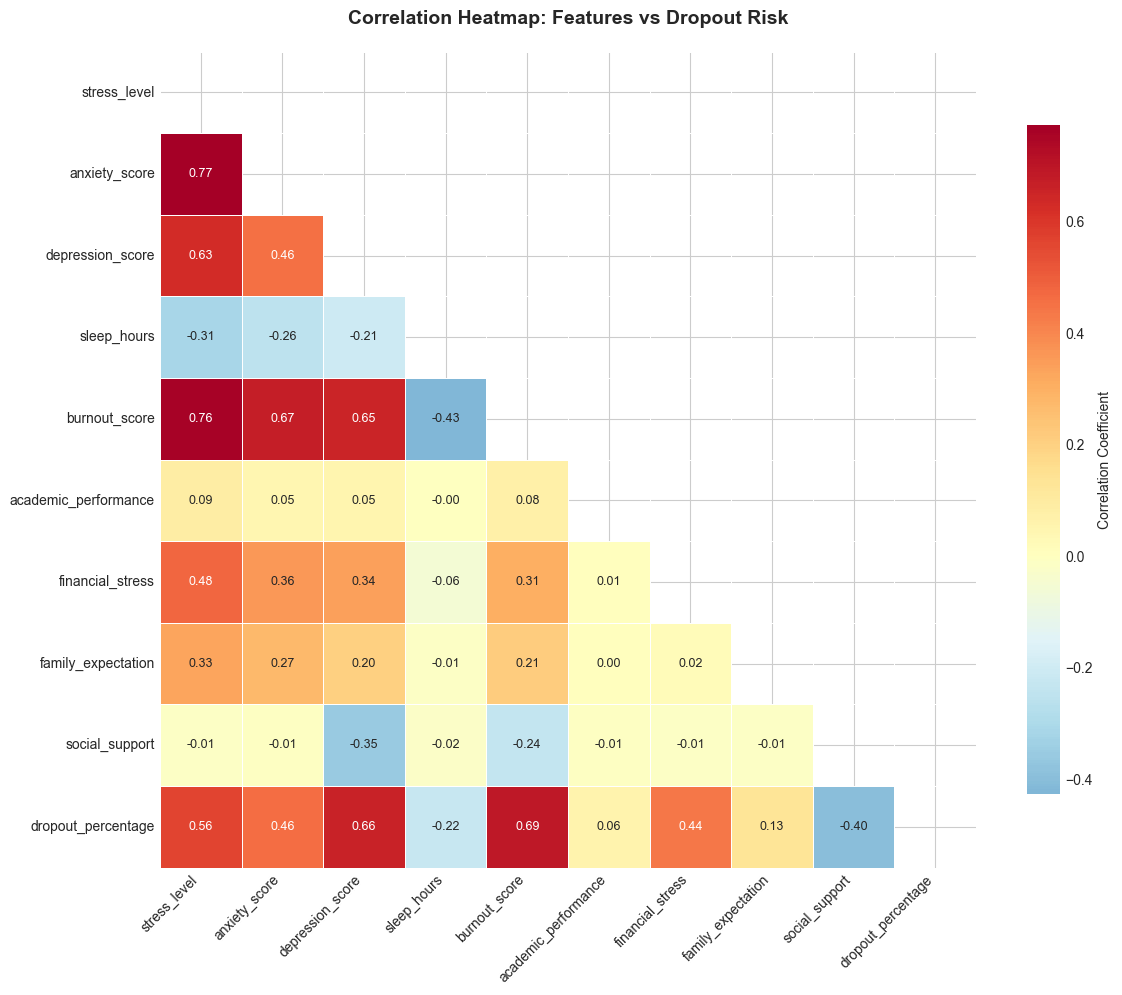


📌 FEATURE SELECTION RATIONALE:
--------------------------------------------------

Correlation with Dropout Risk (sorted by strength):

   burnout_score             | r = +0.692 | Strong   | ↑ Higher = More Risk
   depression_score          | r = +0.660 | Strong   | ↑ Higher = More Risk
   stress_level              | r = +0.562 | Strong   | ↑ Higher = More Risk
   anxiety_score             | r = +0.461 | Moderate | ↑ Higher = More Risk
   financial_stress          | r = +0.438 | Moderate | ↑ Higher = More Risk
   social_support            | r = -0.398 | Moderate | ↓ Higher = Less Risk
   sleep_hours               | r = -0.223 | Weak     | ↓ Higher = Less Risk
   family_expectation        | r = +0.126 | Weak     | ↑ Higher = More Risk
   academic_performance      | r = +0.058 | Weak     | ↑ Higher = More Risk

💡 Key Insights:
   • Features with |correlation| > 0.3 are meaningful predictors
   • Positive correlation: as feature increases, dropout risk increases
   • Negative correlation

In [4]:
# =============================================================================
# SECTION 3: FEATURE SELECTION
# =============================================================================

print("=" * 60)
print("FEATURE SELECTION")
print("=" * 60)

# Define the important features we want to use
important_features = [
    'stress_level',
    'anxiety_score', 
    'depression_score',
    'sleep_hours',
    'burnout_score',
    'academic_performance',
    'financial_stress',
    'family_expectation',
    'social_support'
]

# Check which features exist in the dataset
available_features = []
missing_features = []

for feature in important_features:
    # Check for exact match or similar names (case-insensitive)
    found = False
    for col in data.columns:
        if feature.lower().replace('_', '') in col.lower().replace('_', ''):
            available_features.append(col)
            found = True
            break
    if not found:
        missing_features.append(feature)

print(f"\n✅ Available features ({len(available_features)}):")
for f in available_features:
    print(f"   • {f}")

if missing_features:
    print(f"\n⚠️ Features not found ({len(missing_features)}):")
    for f in missing_features:
        print(f"   • {f}")
    print("\nNote: The model will use available features only.")

# --- 3.1 Correlation Heatmap ---
print("\n" + "=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

# Select numerical columns including our target
correlation_cols = available_features + ['dropout_percentage']
correlation_cols = [col for col in correlation_cols if col in data.columns]

correlation_matrix = data[correlation_cols].corr()

# Create a larger, clearer heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Upper triangle mask

heatmap = sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
    annot_kws={'size': 9}
)

plt.title('Correlation Heatmap: Features vs Dropout Risk', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- 3.2 Why These Features Were Selected ---
print("\n📌 FEATURE SELECTION RATIONALE:")
print("-" * 50)

# Calculate and display correlation with target
correlations_with_target = data[correlation_cols].corr()['dropout_percentage'].drop('dropout_percentage').sort_values(key=abs, ascending=False)

print("\nCorrelation with Dropout Risk (sorted by strength):\n")
for feature, corr in correlations_with_target.items():
    direction = "↑ Higher = More Risk" if corr > 0 else "↓ Higher = Less Risk"
    strength = "Strong" if abs(corr) > 0.5 else "Moderate" if abs(corr) > 0.3 else "Weak"
    print(f"   {feature:25s} | r = {corr:+.3f} | {strength:8s} | {direction}")

print("\n💡 Key Insights:")
print("   • Features with |correlation| > 0.3 are meaningful predictors")
print("   • Positive correlation: as feature increases, dropout risk increases")
print("   • Negative correlation: as feature increases, dropout risk decreases")
print("   • Selected features cover mental health, academic, and social factors")


EXPLORATORY DATA ANALYSIS


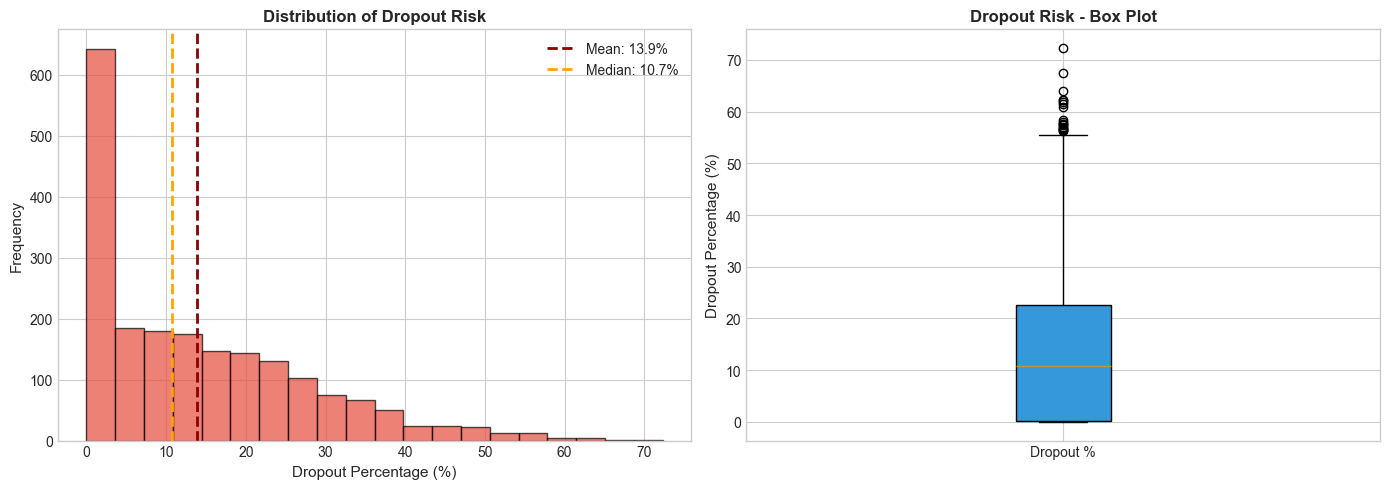


📊 Distribution of Key Features:


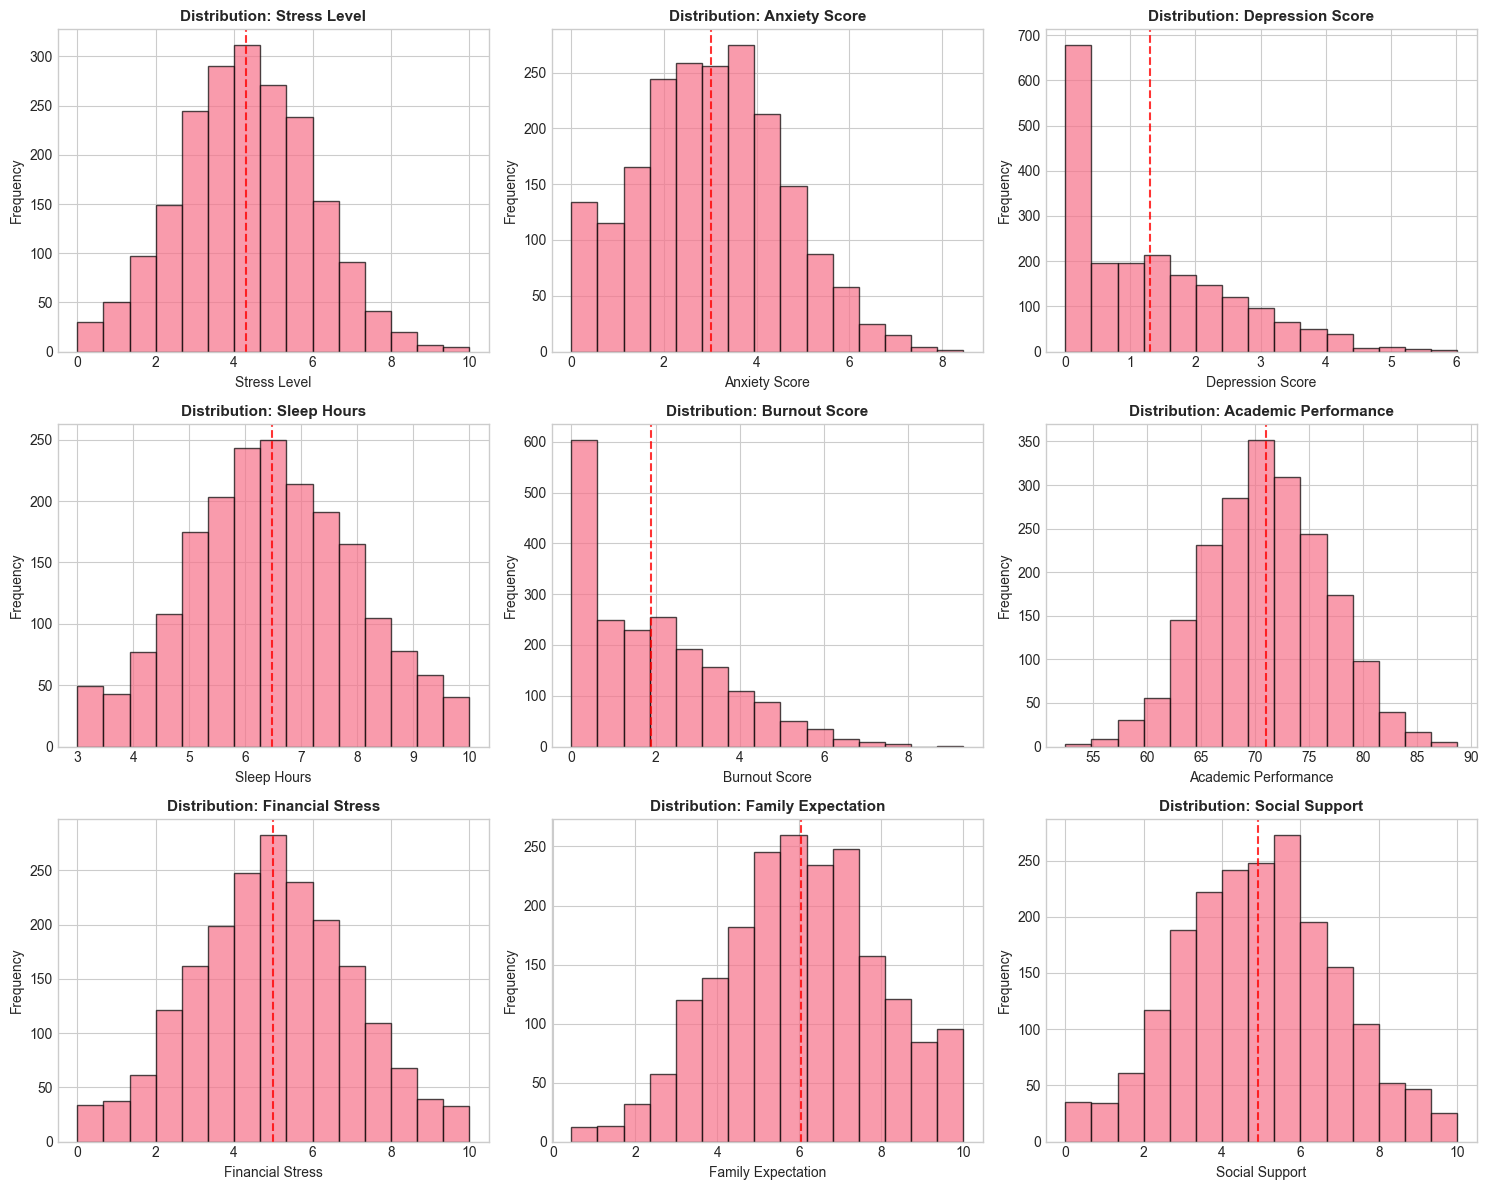


📊 Relationship Between Features and Dropout Risk:


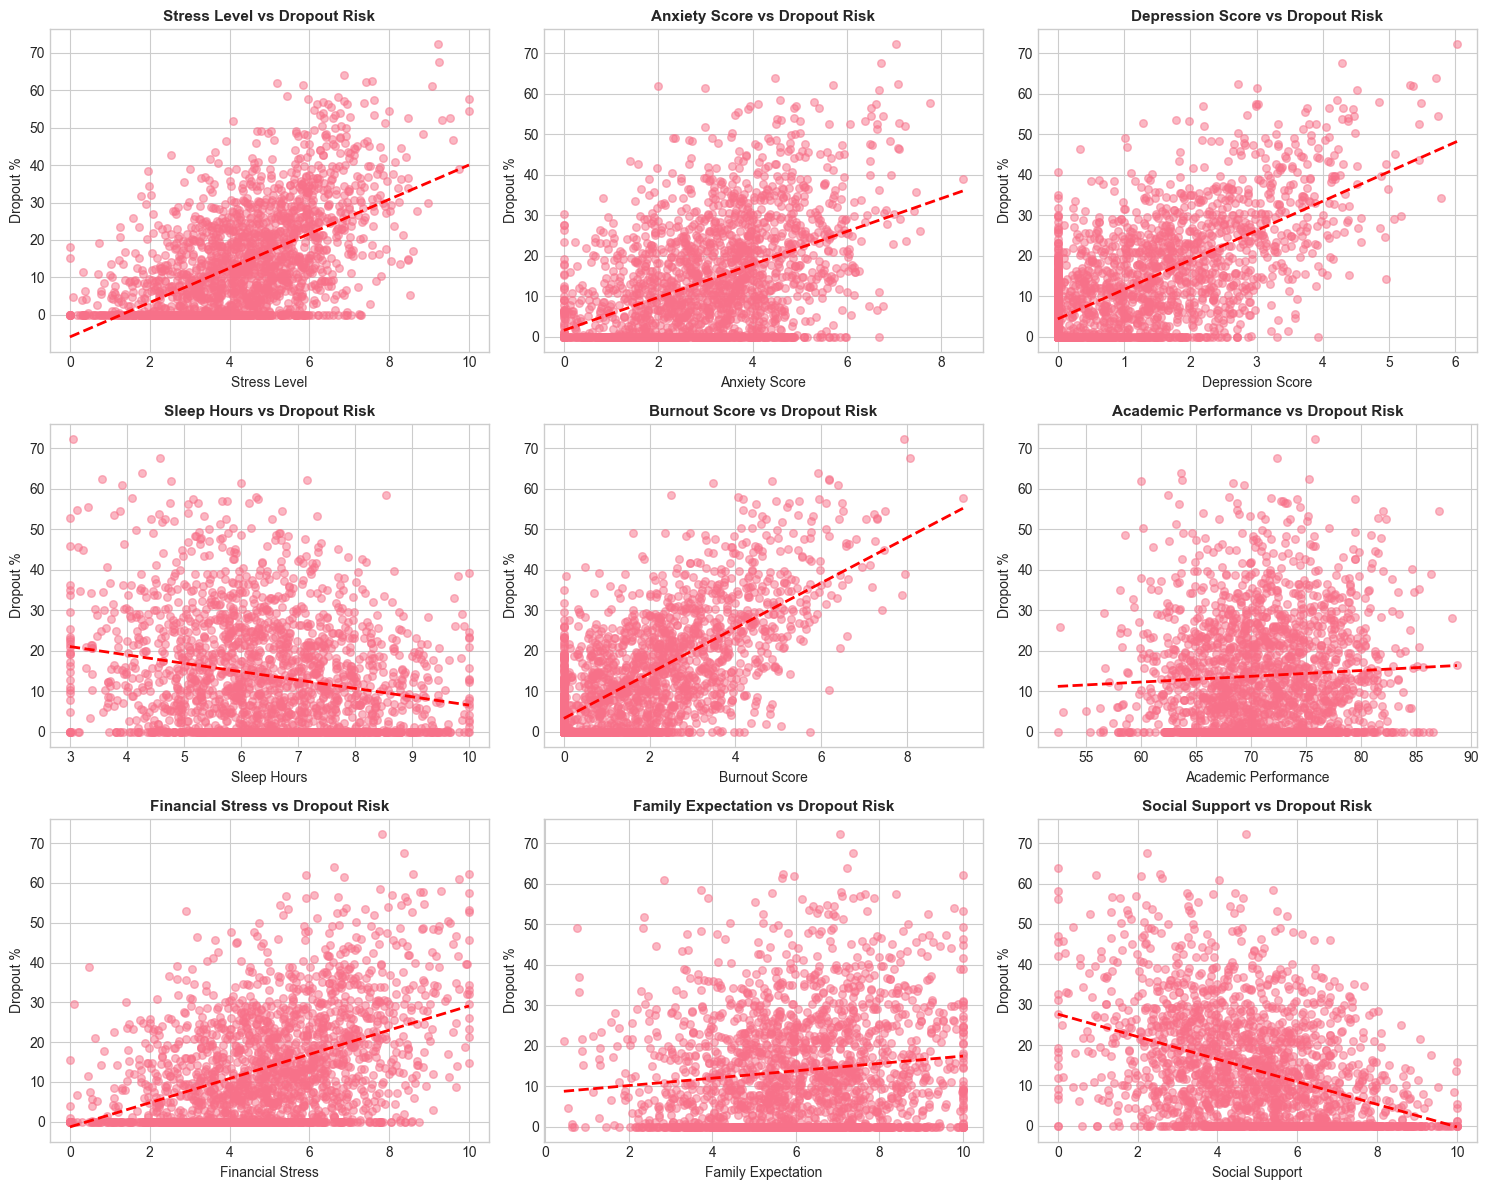


📈 Statistical Summary of Selected Features:
----------------------------------------------------------------------
       stress_level  anxiety_score  depression_score  sleep_hours  burnout_score  academic_performance  financial_stress  family_expectation  social_support  dropout_percentage
count       1999.00        1999.00           1999.00      1999.00        1999.00               1999.00           1999.00             1999.00         1999.00             1999.00
mean           4.30           3.01              1.30         6.48           1.89                 71.05              5.00                6.03            4.93               13.88
std            1.70           1.57              1.26         1.50           1.72                  5.62              2.00                1.93            1.97               13.86
min            0.00           0.00              0.00         3.00           0.00                 52.43              0.00                0.44            0.00                0.00

In [5]:
# =============================================================================
# SECTION 4: EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================================

print("=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# --- 4.1 Distribution of Target Variable ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(data['dropout_percentage'], bins=20, edgecolor='black', alpha=0.7, color='#e74c3c')
axes[0].axvline(data['dropout_percentage'].mean(), color='darkred', linestyle='--', linewidth=2, label=f'Mean: {data["dropout_percentage"].mean():.1f}%')
axes[0].axvline(data['dropout_percentage'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {data["dropout_percentage"].median():.1f}%')
axes[0].set_xlabel('Dropout Percentage (%)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of Dropout Risk', fontsize=12, fontweight='bold')
axes[0].legend()

# Box plot
bp = axes[1].boxplot(data['dropout_percentage'], patch_artist=True)
bp['boxes'][0].set_facecolor('#3498db')
axes[1].set_ylabel('Dropout Percentage (%)', fontsize=11)
axes[1].set_title('Dropout Risk - Box Plot', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(['Dropout %'])

plt.tight_layout()
plt.show()

# --- 4.2 Distribution of Key Features ---
print("\n📊 Distribution of Key Features:")

n_features = len(available_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for idx, feature in enumerate(available_features):
    if feature in data.columns:
        axes[idx].hist(data[feature], bins=15, edgecolor='black', alpha=0.7)
        axes[idx].set_xlabel(feature.replace('_', ' ').title(), fontsize=10)
        axes[idx].set_ylabel('Frequency', fontsize=10)
        axes[idx].set_title(f'Distribution: {feature.replace("_", " ").title()}', fontsize=11, fontweight='bold')
        
        # Add mean line
        mean_val = data[feature].mean()
        axes[idx].axvline(mean_val, color='red', linestyle='--', alpha=0.8)

# Hide empty subplots
for idx in range(len(available_features), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# --- 4.3 Feature vs Target Scatter Plots ---
print("\n📊 Relationship Between Features and Dropout Risk:")

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, feature in enumerate(available_features[:9]):  # First 9 features
    if feature in data.columns:
        axes[idx].scatter(data[feature], data['dropout_percentage'], alpha=0.5, s=30)
        
        # Add trend line
        z = np.polyfit(data[feature], data['dropout_percentage'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(data[feature].min(), data[feature].max(), 100)
        axes[idx].plot(x_line, p(x_line), "r--", linewidth=2, label='Trend')
        
        axes[idx].set_xlabel(feature.replace('_', ' ').title(), fontsize=10)
        axes[idx].set_ylabel('Dropout %', fontsize=10)
        axes[idx].set_title(f'{feature.replace("_", " ").title()} vs Dropout Risk', fontsize=11, fontweight='bold')

# Hide empty subplots
for idx in range(len(available_features), len(axes)):
    if idx < len(axes):
        axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# --- 4.4 Statistical Summary ---
print("\n📈 Statistical Summary of Selected Features:")
print("-" * 70)
print(data[available_features + ['dropout_percentage']].describe().round(2).to_string())


In [6]:
# =============================================================================
# SECTION 5: PREPARE DATA FOR MODEL TRAINING
# =============================================================================

print("=" * 60)
print("PREPARING DATA FOR MODELING")
print("=" * 60)

# Select features (X) and target (y)
X = data[available_features].copy()
y = data['dropout_percentage'].copy()

print(f"\n📊 Feature Matrix Shape: {X.shape}")
print(f"📊 Target Vector Shape: {y.shape}")

# --- 5.1 Handle any remaining non-numeric values ---
# Ensure all features are numeric
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

# --- 5.2 Standardize/Normalize Features ---
print("\n🔧 Standardizing features (mean=0, std=1)...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("✅ Features standardized!")
print("\nBefore scaling (first row):", X.iloc[0].values[:3].round(2), "...")
print("After scaling (first row):", X_scaled.iloc[0].values[:3].round(2), "...")

# --- 5.3 Train-Test Split (80-20) ---
print("\n📂 Splitting data into train (80%) and test (20%) sets...")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, 
    y, 
    test_size=0.20, 
    random_state=42  # For reproducibility
)

print(f"   Training set: {X_train.shape[0]} samples")
print(f"   Test set: {X_test.shape[0]} samples")
print("\n✅ Data preparation complete!")


PREPARING DATA FOR MODELING

📊 Feature Matrix Shape: (1999, 9)
📊 Target Vector Shape: (1999,)

🔧 Standardizing features (mean=0, std=1)...
✅ Features standardized!

Before scaling (first row): [4.12 2.28 1.99] ...
After scaling (first row): [-0.11 -0.47  0.55] ...

📂 Splitting data into train (80%) and test (20%) sets...
   Training set: 1599 samples
   Test set: 400 samples

✅ Data preparation complete!


In [7]:
!pip install xgboost


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# =============================================================================
# SECTION 6: MODEL BUILDING AND TRAINING
# =============================================================================

print("=" * 60)
print("MODEL TRAINING")
print("=" * 60)

# Dictionary to store models and their results
models = {}
results = {}

# --- 6.1 Linear Regression ---
print("\n🔹 Training Model 1: Linear Regression...")

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

models['Linear Regression'] = lr_model
print("   ✅ Linear Regression trained!")

# --- 6.2 Random Forest Regressor ---
print("\n🔹 Training Model 2: Random Forest Regressor...")

rf_model = RandomForestRegressor(
    n_estimators=100,      # Number of trees
    max_depth=10,          # Maximum depth of trees
    min_samples_split=5,   # Minimum samples to split
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

models['Random Forest'] = rf_model
print("   ✅ Random Forest trained!")

# --- 6.3 XGBoost Regressor ---
print("\n🔹 Training Model 3: XGBoost Regressor...")

try:
    from xgboost import XGBRegressor
    
    xgb_model = XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train)
    xgb_predictions = xgb_model.predict(X_test)
    
    models['XGBoost'] = xgb_model
    print("   ✅ XGBoost trained!")
    
except ImportError:
    print("   ⚠️ XGBoost not installed. Skipping...")
    print("   To install: pip install xgboost")
    xgb_predictions = None

print("\n✅ All models trained successfully!")


MODEL TRAINING

🔹 Training Model 1: Linear Regression...
   ✅ Linear Regression trained!

🔹 Training Model 2: Random Forest Regressor...
   ✅ Random Forest trained!

🔹 Training Model 3: XGBoost Regressor...
   ✅ XGBoost trained!

✅ All models trained successfully!


MODEL EVALUATION METRICS

📊 Model Performance Comparison:
------------------------------------------------------------
                   R² Score     MAE    RMSE
Model                                      
Linear Regression    0.6338  6.5987  8.4200
Random Forest        0.6001  6.9087  8.7987
XGBoost              0.5800  7.0997  9.0180


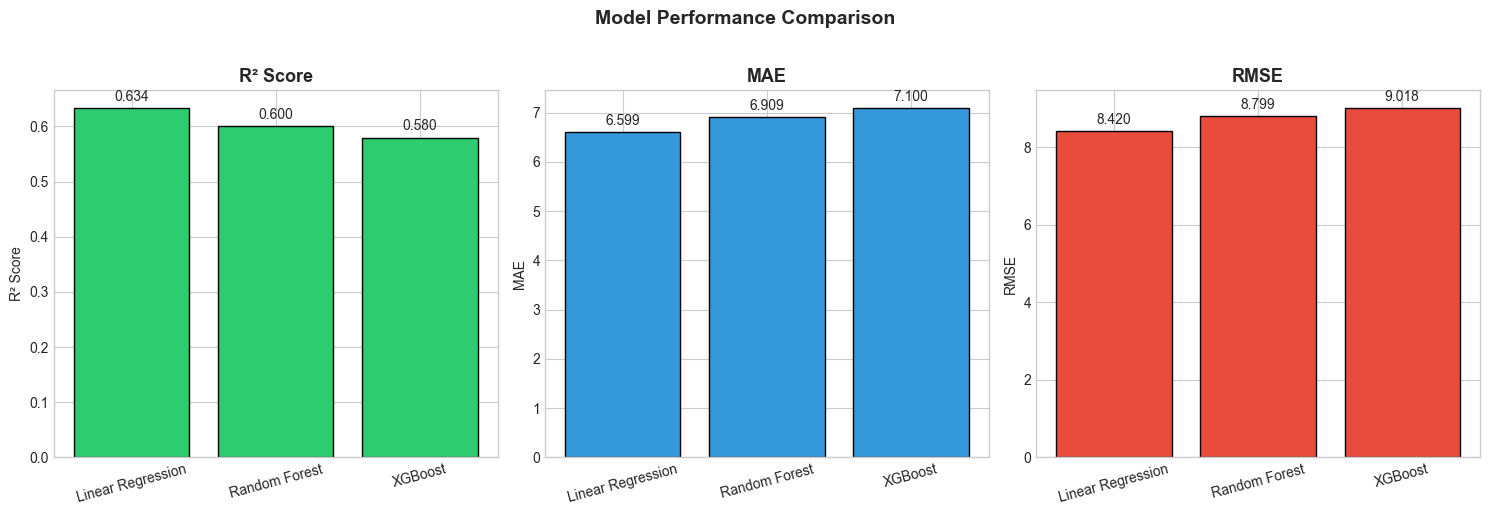


🏆 Best Model: Linear Regression
   R² Score: 0.6338 (63.4% variance explained)
   MAE: 6.60% average error
   RMSE: 8.42%


In [9]:
# =============================================================================
# SECTION 7: MODEL EVALUATION
# =============================================================================

print("=" * 60)
print("MODEL EVALUATION METRICS")
print("=" * 60)

def evaluate_model(y_true, y_pred, model_name):
    """Calculate and return evaluation metrics."""
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    return {
        'Model': model_name,
        'R² Score': r2,
        'MAE': mae,
        'RMSE': rmse
    }

# Evaluate all models
evaluation_results = []

# Linear Regression
lr_results = evaluate_model(y_test, lr_predictions, 'Linear Regression')
evaluation_results.append(lr_results)

# Random Forest
rf_results = evaluate_model(y_test, rf_predictions, 'Random Forest')
evaluation_results.append(rf_results)

# XGBoost (if available)
if 'XGBoost' in models:
    xgb_results = evaluate_model(y_test, xgb_predictions, 'XGBoost')
    evaluation_results.append(xgb_results)

# Create results dataframe
results_df = pd.DataFrame(evaluation_results)
results_df = results_df.set_index('Model')

print("\n📊 Model Performance Comparison:")
print("-" * 60)
print(results_df.round(4).to_string())

# --- Visual Comparison ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['R² Score', 'MAE', 'RMSE']
colors = ['#2ecc71', '#3498db', '#e74c3c']

for idx, metric in enumerate(metrics):
    bars = axes[idx].bar(results_df.index, results_df[metric], color=colors[idx], edgecolor='black')
    axes[idx].set_title(metric, fontsize=13, fontweight='bold')
    axes[idx].set_ylabel(metric)
    axes[idx].tick_params(axis='x', rotation=15)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[idx].annotate(f'{height:.3f}',
                          xy=(bar.get_x() + bar.get_width() / 2, height),
                          xytext=(0, 3),
                          textcoords="offset points",
                          ha='center', va='bottom', fontsize=10)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Identify Best Model ---
best_model_name = results_df['R² Score'].idxmax()
best_r2 = results_df.loc[best_model_name, 'R² Score']

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   R² Score: {best_r2:.4f} ({best_r2*100:.1f}% variance explained)")
print(f"   MAE: {results_df.loc[best_model_name, 'MAE']:.2f}% average error")
print(f"   RMSE: {results_df.loc[best_model_name, 'RMSE']:.2f}%")

best_model = models[best_model_name]


MAKING PREDICTIONS


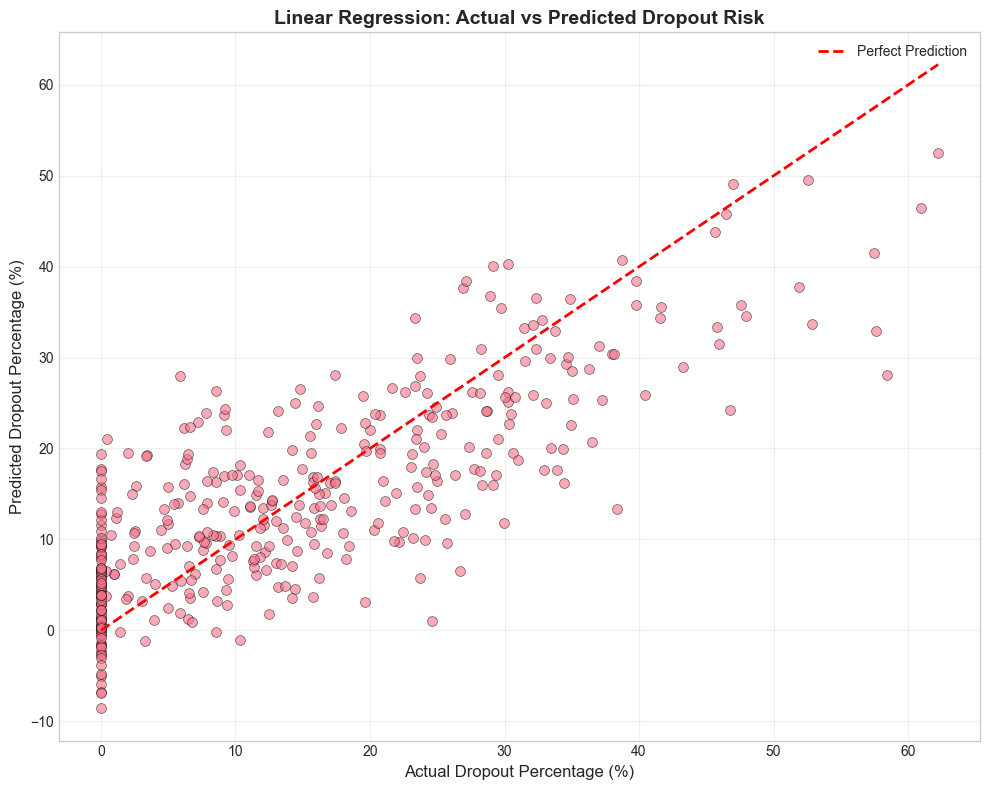


📋 SAMPLE PREDICTION FOR A NEW STUDENT:
--------------------------------------------------

Sample Student Profile:
   stress_level             : 4.28
   anxiety_score            : 3.03
   depression_score         : 1.04
   sleep_hours              : 6.45
   burnout_score            : 1.64
   academic_performance     : 71.01
   financial_stress         : 4.97
   family_expectation       : 5.99
   social_support           : 4.92

🎯 PREDICTED DROPOUT PROBABILITY: 12.2%
📊 RISK LEVEL: LOW RISK 🟢
💡 RECOMMENDATION: Student appears stable. Continue monitoring.

CUSTOM PREDICTION FUNCTION

💡 Example: Predicting for a high-stress student
   Predicted Dropout Risk: 53.2%


In [10]:
# =============================================================================
# SECTION 8: PREDICTIONS
# =============================================================================

print("=" * 60)
print("MAKING PREDICTIONS")
print("=" * 60)

# --- 8.1 Actual vs Predicted Plot ---
if best_model_name == 'Linear Regression':
    best_predictions = lr_predictions
elif best_model_name == 'Random Forest':
    best_predictions = rf_predictions
else:
    best_predictions = xgb_predictions

plt.figure(figsize=(10, 8))
plt.scatter(y_test, best_predictions, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Dropout Percentage (%)', fontsize=12)
plt.ylabel('Predicted Dropout Percentage (%)', fontsize=12)
plt.title(f'{best_model_name}: Actual vs Predicted Dropout Risk', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 8.2 Sample Prediction for a New Student ---
print("\n📋 SAMPLE PREDICTION FOR A NEW STUDENT:")
print("-" * 50)

# Create a sample student profile (adjust values as needed)
sample_student = {}
print("\nSample Student Profile:")

# Use median values from training data as defaults
for feature in available_features:
    median_val = X[feature].median()
    sample_student[feature] = median_val
    print(f"   {feature:25s}: {median_val:.2f}")

# Create DataFrame for prediction
sample_df = pd.DataFrame([sample_student])

# Scale the sample
sample_scaled = scaler.transform(sample_df)

# Predict with best model
predicted_dropout = best_model.predict(sample_scaled)[0]

# Ensure prediction is within valid range (0-100%)
predicted_dropout = max(0, min(100, predicted_dropout))

print(f"\n🎯 PREDICTED DROPOUT PROBABILITY: {predicted_dropout:.1f}%")

# Risk level interpretation
if predicted_dropout < 30:
    risk_level = "LOW RISK 🟢"
    recommendation = "Student appears stable. Continue monitoring."
elif predicted_dropout < 60:
    risk_level = "MODERATE RISK 🟡"
    recommendation = "Consider early intervention and support services."
else:
    risk_level = "HIGH RISK 🔴"
    recommendation = "Urgent intervention needed. Recommend counseling and academic support."

print(f"📊 RISK LEVEL: {risk_level}")
print(f"💡 RECOMMENDATION: {recommendation}")

# --- 8.3 Interactive Prediction Function ---
print("\n" + "=" * 60)
print("CUSTOM PREDICTION FUNCTION")
print("=" * 60)

def predict_dropout_risk(stress, anxiety, depression, sleep, burnout, 
                         academic, financial, family, social):
    """
    Predict dropout risk for a student given their characteristics.
    
    Parameters (all on scale appropriate to your dataset):
    - stress: Stress level
    - anxiety: Anxiety score  
    - depression: Depression score
    - sleep: Sleep hours
    - burnout: Burnout score
    - academic: Academic performance
    - financial: Financial stress
    - family: Family expectation
    - social: Social support
    
    Returns:
    - Dropout probability (0-100%)
    """
    # Create input array
    input_data = {
        'stress_level': stress,
        'anxiety_score': anxiety,
        'depression_score': depression,
        'sleep_hours': sleep,
        'burnout_score': burnout,
        'academic_performance': academic,
        'financial_stress': financial,
        'family_expectation': family,
        'social_support': social
    }
    
    # Match to available features
    input_values = {}
    for feature in available_features:
        for key, value in input_data.items():
            if key.lower().replace('_', '') in feature.lower().replace('_', ''):
                input_values[feature] = value
                break
    
    # Create DataFrame and scale
    input_df = pd.DataFrame([input_values])
    input_scaled = scaler.transform(input_df)
    
    # Predict
    prediction = best_model.predict(input_scaled)[0]
    prediction = max(0, min(100, prediction))
    
    return prediction

# Example usage
print("\n💡 Example: Predicting for a high-stress student")
example_prediction = predict_dropout_risk(
    stress=8,      # High stress
    anxiety=7,     # High anxiety
    depression=6,  # Moderate depression
    sleep=4,       # Low sleep
    burnout=8,     # High burnout
    academic=5,    # Average performance
    financial=7,   # High financial stress
    family=8,      # High family expectations
    social=3       # Low social support
)
print(f"   Predicted Dropout Risk: {example_prediction:.1f}%")


FEATURE IMPORTANCE ANALYSIS


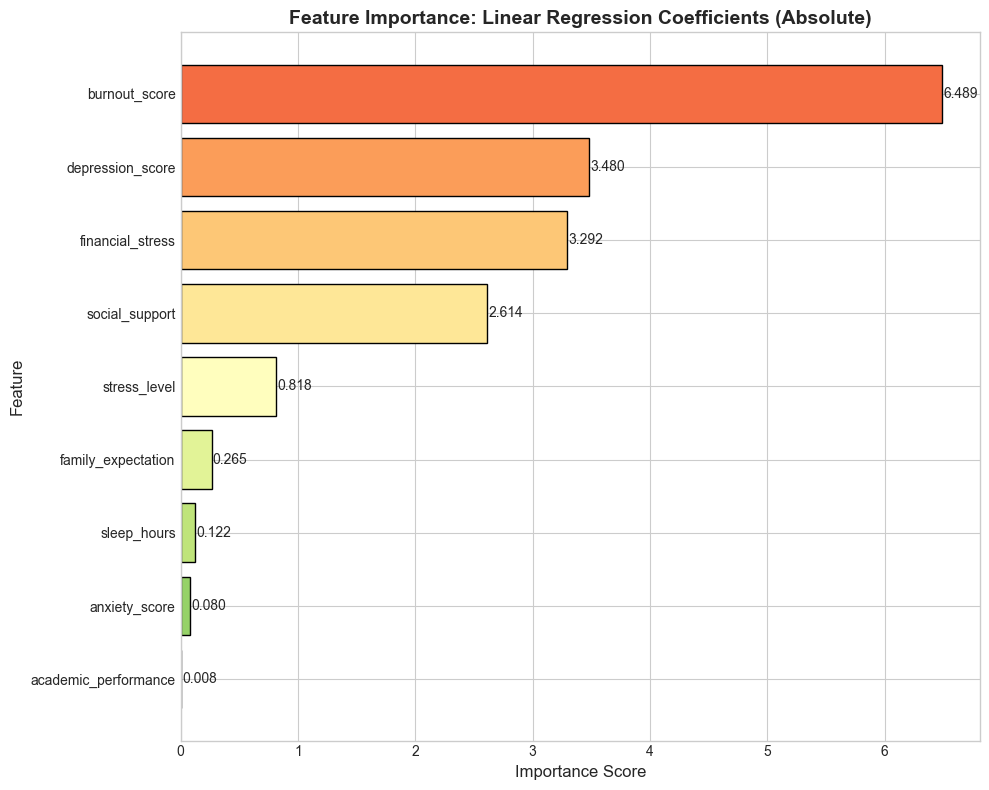


📊 Feature Importance Ranking (Most to Least Important):
--------------------------------------------------
   1. burnout_score             ████████████████████ 6.4894
   2. depression_score          ██████████░░░░░░░░░░ 3.4803
   3. financial_stress          ██████████░░░░░░░░░░ 3.2918
   4. social_support            ████████░░░░░░░░░░░░ 2.6136
   5. stress_level              ██░░░░░░░░░░░░░░░░░░ 0.8178
   6. family_expectation        ░░░░░░░░░░░░░░░░░░░░ 0.2646
   7. sleep_hours               ░░░░░░░░░░░░░░░░░░░░ 0.1217
   8. anxiety_score             ░░░░░░░░░░░░░░░░░░░░ 0.0799
   9. academic_performance      ░░░░░░░░░░░░░░░░░░░░ 0.0080

💡 KEY FINDINGS:
   The top 3 factors driving dropout risk are:
      1. Burnout Score
      2. Depression Score
      3. Financial Stress


In [11]:
# =============================================================================
# SECTION 9: FEATURE IMPORTANCE
# =============================================================================

print("=" * 60)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

# --- Get Feature Importance from Best Model ---

if best_model_name == 'Random Forest':
    importances = best_model.feature_importances_
    importance_type = "Random Forest Feature Importance"
    
elif best_model_name == 'XGBoost':
    importances = best_model.feature_importances_
    importance_type = "XGBoost Feature Importance"
    
else:  # Linear Regression - use absolute coefficients
    importances = np.abs(lr_model.coef_)
    importance_type = "Linear Regression Coefficients (Absolute)"

# Create importance DataFrame
importance_df = pd.DataFrame({
    'Feature': available_features,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# Plot feature importance
plt.figure(figsize=(10, 8))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(importance_df)))

bars = plt.barh(importance_df['Feature'], importance_df['Importance'], color=colors, edgecolor='black')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Feature Importance: {importance_type}', fontsize=14, fontweight='bold')

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# --- Display Importance Ranking ---
print("\n📊 Feature Importance Ranking (Most to Least Important):")
print("-" * 50)

importance_df_sorted = importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)
importance_df_sorted.index = importance_df_sorted.index + 1

for idx, row in importance_df_sorted.iterrows():
    bar_length = int(row['Importance'] / importance_df_sorted['Importance'].max() * 20)
    bar = '█' * bar_length + '░' * (20 - bar_length)
    print(f"   {idx}. {row['Feature']:25s} {bar} {row['Importance']:.4f}")

# Top 3 insights
print("\n💡 KEY FINDINGS:")
top_3 = importance_df_sorted.head(3)['Feature'].tolist()
print(f"   The top 3 factors driving dropout risk are:")
for i, feature in enumerate(top_3, 1):
    print(f"      {i}. {feature.replace('_', ' ').title()}")


In [12]:
# =============================================================================
# SECTION 10: KEY INSIGHTS AND CONCLUSIONS
# =============================================================================

print("=" * 60)
print("KEY INSIGHTS AND CONCLUSIONS")
print("=" * 60)

# --- Calculate insights from the data ---

# 1. Correlation insights
high_risk_corr = correlations_with_target[correlations_with_target > 0.3]
protective_factors = correlations_with_target[correlations_with_target < -0.2]

print("\n📈 DATA-DRIVEN INSIGHTS:")
print("-" * 50)

print("\n1️⃣ RISK FACTORS (Positively correlated with dropout):")
for feature, corr in high_risk_corr.items():
    print(f"   • Higher {feature.replace('_', ' ')} → Higher dropout risk (r={corr:.3f})")

print("\n2️⃣ PROTECTIVE FACTORS (Negatively correlated with dropout):")
if len(protective_factors) > 0:
    for feature, corr in protective_factors.items():
        print(f"   • Higher {feature.replace('_', ' ')} → Lower dropout risk (r={corr:.3f})")
else:
    print("   • No strong protective factors identified in selected features")

# 3. Model insights
print(f"\n3️⃣ MODEL PERFORMANCE:")
print(f"   • Best model: {best_model_name}")
print(f"   • Explains {best_r2*100:.1f}% of variance in dropout risk")
print(f"   • Average prediction error: ±{results_df.loc[best_model_name, 'MAE']:.2f}%")

# 4. Threshold-based insights
print("\n4️⃣ RISK DISTRIBUTION IN DATASET:")
low_risk = (data['dropout_percentage'] < 30).sum()
moderate_risk = ((data['dropout_percentage'] >= 30) & (data['dropout_percentage'] < 60)).sum()
high_risk = (data['dropout_percentage'] >= 60).sum()

total = len(data)
print(f"   • Low Risk (<30%):     {low_risk:4d} students ({low_risk/total*100:.1f}%)")
print(f"   • Moderate Risk:       {moderate_risk:4d} students ({moderate_risk/total*100:.1f}%)")
print(f"   • High Risk (≥60%):    {high_risk:4d} students ({high_risk/total*100:.1f}%)")

# 5. Actionable recommendations
print("\n5️⃣ RECOMMENDATIONS FOR INTERVENTION:")
print("-" * 50)

top_feature = importance_df_sorted.iloc[0]['Feature']
second_feature = importance_df_sorted.iloc[1]['Feature']
third_feature = importance_df_sorted.iloc[2]['Feature']

recommendations = f"""
   Based on the analysis, here are key intervention strategies:

   🎯 Priority 1: Address {top_feature.replace('_', ' ').title()}
      → This is the strongest predictor of dropout risk
      → Early screening and intervention programs recommended

   🎯 Priority 2: Monitor {second_feature.replace('_', ' ').title()}
      → Second most important factor
      → Regular assessments and support systems needed

   🎯 Priority 3: Support {third_feature.replace('_', ' ').title()}
      → Third key factor affecting student retention
      → Consider targeted workshops and resources

   📋 General Recommendations:
      • Implement early warning systems based on these factors
      • Provide mental health resources and counseling
      • Create peer support networks
      • Regular check-ins for at-risk students
      • Academic support and tutoring programs
"""
print(recommendations)


KEY INSIGHTS AND CONCLUSIONS

📈 DATA-DRIVEN INSIGHTS:
--------------------------------------------------

1️⃣ RISK FACTORS (Positively correlated with dropout):
   • Higher burnout score → Higher dropout risk (r=0.692)
   • Higher depression score → Higher dropout risk (r=0.660)
   • Higher stress level → Higher dropout risk (r=0.562)
   • Higher anxiety score → Higher dropout risk (r=0.461)
   • Higher financial stress → Higher dropout risk (r=0.438)

2️⃣ PROTECTIVE FACTORS (Negatively correlated with dropout):
   • Higher social support → Lower dropout risk (r=-0.398)
   • Higher sleep hours → Lower dropout risk (r=-0.223)

3️⃣ MODEL PERFORMANCE:
   • Best model: Linear Regression
   • Explains 63.4% of variance in dropout risk
   • Average prediction error: ±6.60%

4️⃣ RISK DISTRIBUTION IN DATASET:
   • Low Risk (<30%):     1731 students (86.6%)
   • Moderate Risk:        260 students (13.0%)
   • High Risk (≥60%):       8 students (0.4%)

5️⃣ RECOMMENDATIONS FOR INTERVENTION:
-----

RULE-BASED CLASSIFICATION SYSTEM

📊 COMPARISON: Rule-Based vs ML-Based Classification
------------------------------------------------------------

📋 Confusion Matrix:
ml_risk          LOW RISK  MODERATE RISK  Total
rule_based_risk                                
HIGH RISK               0             20     20
LOW RISK             1797            147   1944
MODERATE RISK          14             21     35
Total                1811            188   1999

✅ Agreement Rate: 90.9%
   (1818 out of 1999 students classified the same way)

📊 Risk Distribution Comparison:
----------------------------------------
               Rule-Based (%)  ML-Based (%)
HIGH RISK                 1.0           0.0
LOW RISK                 97.2          90.6
MODERATE RISK             1.8           9.4


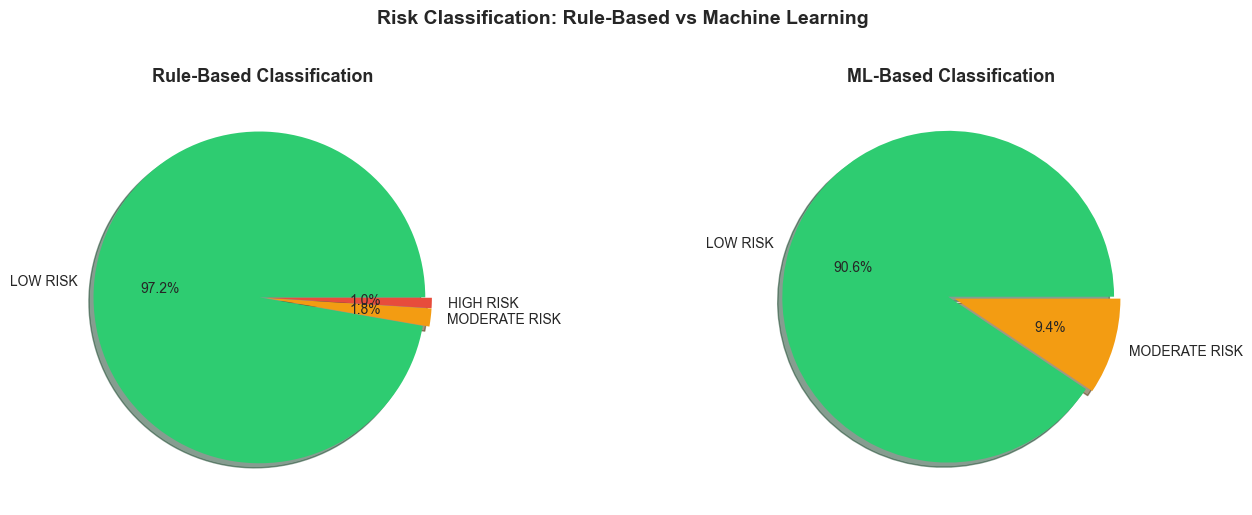


🔍 ANALYSIS OF DISAGREEMENTS:
--------------------------------------------------
   Total disagreements: 181 (9.1% of data)

   Most common disagreement patterns:
      Rule: LOW RISK        → ML: MODERATE RISK   (147 cases)
      Rule: HIGH RISK       → ML: MODERATE RISK   (20 cases)
      Rule: MODERATE RISK   → ML: LOW RISK        (14 cases)

💡 CONCLUSION:
--------------------------------------------------

   The rule-based system uses simple threshold logic:
   • stress > 7 AND sleep < 5 AND burnout > 6 → HIGH RISK

   The ML model (Linear Regression) considers:
   • All 9 features simultaneously
   • Non-linear relationships between features
   • Learned patterns from the training data

   Agreement Rate: 90.9%

   The high agreement suggests the simple rules capture the main patterns.

   Recommendation: Use ML model for nuanced predictions, rule-based
   system for quick screening and easily explainable decisions.



In [13]:
# =============================================================================
# SECTION 11: RULE-BASED SYSTEM (BONUS)
# =============================================================================

print("=" * 60)
print("RULE-BASED CLASSIFICATION SYSTEM")
print("=" * 60)

# --- Define Rule-Based Classification ---

def rule_based_risk(row):
    """
    Simple rule-based system for dropout risk classification.
    
    Rules:
    - HIGH RISK: stress > 7 AND sleep < 5 AND burnout > 6
    - MODERATE RISK: Any two of the above conditions
    - LOW RISK: Otherwise
    """
    # Find the actual column names in the data
    stress_col = None
    sleep_col = None
    burnout_col = None
    
    for col in row.index:
        if 'stress' in col.lower() and 'financial' not in col.lower():
            stress_col = col
        if 'sleep' in col.lower():
            sleep_col = col
        if 'burnout' in col.lower():
            burnout_col = col
    
    # Default values if columns not found
    stress = row[stress_col] if stress_col else 5
    sleep = row[sleep_col] if sleep_col else 7
    burnout = row[burnout_col] if burnout_col else 5
    
    # Normalize to 0-10 scale if needed (adjust based on your data)
    # Assuming values are already on a reasonable scale
    
    high_stress = stress > 7
    low_sleep = sleep < 5
    high_burnout = burnout > 6
    
    conditions_met = sum([high_stress, low_sleep, high_burnout])
    
    if conditions_met == 3:
        return 'HIGH RISK'
    elif conditions_met == 2:
        return 'MODERATE RISK'
    else:
        return 'LOW RISK'

# Apply rule-based classification to entire dataset
data['rule_based_risk'] = data.apply(rule_based_risk, axis=1)

# --- ML-Based Classification (using best model) ---

# Create risk categories from ML predictions
X_all_scaled = scaler.transform(X)
ml_predictions = best_model.predict(X_all_scaled)

def ml_risk_category(prediction):
    if prediction < 30:
        return 'LOW RISK'
    elif prediction < 60:
        return 'MODERATE RISK'
    else:
        return 'HIGH RISK'

data['ml_risk'] = [ml_risk_category(p) for p in ml_predictions]

# --- Compare the Two Approaches ---

print("\n📊 COMPARISON: Rule-Based vs ML-Based Classification")
print("-" * 60)

# Cross-tabulation
comparison_table = pd.crosstab(
    data['rule_based_risk'], 
    data['ml_risk'],
    margins=True,
    margins_name='Total'
)
print("\n📋 Confusion Matrix:")
print(comparison_table.to_string())

# Agreement rate
agreement = (data['rule_based_risk'] == data['ml_risk']).sum()
agreement_rate = agreement / len(data) * 100

print(f"\n✅ Agreement Rate: {agreement_rate:.1f}%")
print(f"   ({agreement} out of {len(data)} students classified the same way)")

# Distribution comparison
print("\n📊 Risk Distribution Comparison:")
print("-" * 40)

rule_dist = data['rule_based_risk'].value_counts(normalize=True) * 100
ml_dist = data['ml_risk'].value_counts(normalize=True) * 100

comparison_df = pd.DataFrame({
    'Rule-Based (%)': rule_dist,
    'ML-Based (%)': ml_dist
}).fillna(0)

print(comparison_df.round(1).to_string())

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rule-based distribution
colors_map = {'LOW RISK': '#2ecc71', 'MODERATE RISK': '#f39c12', 'HIGH RISK': '#e74c3c'}
rule_counts = data['rule_based_risk'].value_counts()
axes[0].pie(rule_counts, labels=rule_counts.index, autopct='%1.1f%%', 
            colors=[colors_map.get(x, '#999') for x in rule_counts.index],
            explode=[0.02]*len(rule_counts), shadow=True)
axes[0].set_title('Rule-Based Classification', fontsize=13, fontweight='bold')

# ML-based distribution
ml_counts = data['ml_risk'].value_counts()
axes[1].pie(ml_counts, labels=ml_counts.index, autopct='%1.1f%%',
            colors=[colors_map.get(x, '#999') for x in ml_counts.index],
            explode=[0.02]*len(ml_counts), shadow=True)
axes[1].set_title('ML-Based Classification', fontsize=13, fontweight='bold')

plt.suptitle('Risk Classification: Rule-Based vs Machine Learning', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Analysis of Disagreements ---
print("\n🔍 ANALYSIS OF DISAGREEMENTS:")
print("-" * 50)

disagreements = data[data['rule_based_risk'] != data['ml_risk']]
print(f"   Total disagreements: {len(disagreements)} ({len(disagreements)/len(data)*100:.1f}% of data)")

if len(disagreements) > 0:
    print("\n   Most common disagreement patterns:")
    disagreement_patterns = disagreements.groupby(['rule_based_risk', 'ml_risk']).size().sort_values(ascending=False)
    for (rule, ml), count in disagreement_patterns.head(5).items():
        print(f"      Rule: {rule:15s} → ML: {ml:15s} ({count} cases)")

print("\n💡 CONCLUSION:")
print("-" * 50)
conclusion = f"""
   The rule-based system uses simple threshold logic:
   • stress > 7 AND sleep < 5 AND burnout > 6 → HIGH RISK
   
   The ML model ({best_model_name}) considers:
   • All {len(available_features)} features simultaneously
   • Non-linear relationships between features
   • Learned patterns from the training data
   
   Agreement Rate: {agreement_rate:.1f}%
   
   {'The high agreement suggests the simple rules capture the main patterns.' if agreement_rate > 70 else 'The moderate/low agreement suggests ML captures additional complexity not in the simple rules.'}
   
   Recommendation: Use ML model for nuanced predictions, rule-based
   system for quick screening and easily explainable decisions.
"""
print(conclusion)


In [14]:
# =============================================================================
# SECTION 12: SAVE MODEL AND FINAL SUMMARY
# =============================================================================

print("=" * 60)
print("SAVING MODEL AND FINAL SUMMARY")
print("=" * 60)

# --- Save the best model (optional) ---
import joblib

# Save model
joblib.dump(best_model, 'dropout_risk_model.pkl')
print("✅ Model saved as 'dropout_risk_model.pkl'")

# Save scaler
joblib.dump(scaler, 'feature_scaler.pkl')
print("✅ Scaler saved as 'feature_scaler.pkl'")

# Save feature list
with open('feature_list.txt', 'w') as f:
    for feature in available_features:
        f.write(feature + '\n')
print("✅ Feature list saved as 'feature_list.txt'")

# --- Final Summary ---
print("\n" + "=" * 60)
print("📋 FINAL SUMMARY")
print("=" * 60)

summary = f"""
┌─────────────────────────────────────────────────────────────┐
│                    PROJECT SUMMARY                          │
├─────────────────────────────────────────────────────────────┤
│  Dataset Size:        {len(data):,} students                     
│  Features Used:       {len(available_features)} features              
│  Target Variable:     Dropout Percentage (0-100%)           
├─────────────────────────────────────────────────────────────┤
│  BEST MODEL: {best_model_name:15s}                          
│  ├─ R² Score:   {best_r2:.4f} ({best_r2*100:.1f}% variance explained)    
│  ├─ MAE:        {results_df.loc[best_model_name, 'MAE']:.2f}%                         
│  └─ RMSE:       {results_df.loc[best_model_name, 'RMSE']:.2f}%                        
├─────────────────────────────────────────────────────────────┤
│  TOP 3 IMPORTANT FEATURES:                                  
│  1. {importance_df_sorted.iloc[0]['Feature']:25s}           
│  2. {importance_df_sorted.iloc[1]['Feature']:25s}           
│  3. {importance_df_sorted.iloc[2]['Feature']:25s}           
├─────────────────────────────────────────────────────────────┤
│  RULE-BASED vs ML AGREEMENT: {agreement_rate:.1f}%              
└─────────────────────────────────────────────────────────────┘
"""
print(summary)

print("\n✅ Pipeline Complete! You can now use 'predict_dropout_risk()' function")
print("   to make predictions for new students.\n")


SAVING MODEL AND FINAL SUMMARY
✅ Model saved as 'dropout_risk_model.pkl'
✅ Scaler saved as 'feature_scaler.pkl'
✅ Feature list saved as 'feature_list.txt'

📋 FINAL SUMMARY

┌─────────────────────────────────────────────────────────────┐
│                    PROJECT SUMMARY                          │
├─────────────────────────────────────────────────────────────┤
│  Dataset Size:        1,999 students                     
│  Features Used:       9 features              
│  Target Variable:     Dropout Percentage (0-100%)           
├─────────────────────────────────────────────────────────────┤
│  BEST MODEL: Linear Regression                          
│  ├─ R² Score:   0.6338 (63.4% variance explained)    
│  ├─ MAE:        6.60%                         
│  └─ RMSE:       8.42%                        
├─────────────────────────────────────────────────────────────┤
│  TOP 3 IMPORTANT FEATURES:                                  
│  1. burnout_score                       
│  2. depression_

In [15]:
#Use the prediction function for new students:
#python


# Example: Predict for a specific student
risk = predict_dropout_risk(
    stress=8,      # High stress (0-10)
    anxiety=6,     # Moderate anxiety (0-10)
    depression=5,  # Moderate depression (0-10)
    sleep=5,       # 5 hours of sleep
    burnout=7,     # High burnout (0-10)
    academic=4,    # Below average performance (0-10)
    financial=6,   # Moderate financial stress (0-10)
    family=7,      # High family expectations (0-10)
    social=4       # Low social support (0-10)
)
print(f"Dropout Risk: {risk:.1f}%")

Dropout Risk: 44.0%
